# Model Training

# Imports

In [13]:
import joblib
import scipy.sparse as sp
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import numpy as np

## Import feature engineering data

In [14]:
X = sp.load_npz('csv/x_features.npz')
y = pd.read_csv('csv/y_sentiment_labels.csv').squeeze('columns')

print('Loaded features:', X.shape)
print('Loaded labels:', y.shape)

Loaded features: (539794, 128)
Loaded labels: (539794,)


# Training

Finally, a good time to goof around in class justifiably while it trains. 

Seriously though, we need to train the model. 

Using the data from the feature_engineering data stage, we can chuck it into our `LogisticRegression` class to create a model. 

## Splitting

In this section here, we are going to split up our data into a training set and a testing set at 80/20 split. This is crucial because we need some sort of way to test it on unseen data based on existing data. By splitting at 80/20, we are able to train the model on 80% of the total data (about 584,000 rows), while the 20% (roughly 146,000 rows) is kept as testing data. 

By doing this, we are able to prevent overfitting and biased results. 

<!-- found it here: https://www.geeksforgeeks.org/machine-learning/how-to-split-a-dataset-into-train-and-test-sets-using-python/ -->

Scikit conveniently has a function called `train_test_split` that I will use to split into `x_train`, `x_test`, `y_train` and `y_test` (by the name, it's pretty obvious what the purpose of each of the variables are). 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, # 20% testing, 80% testing 
    random_state=42, # used as a seed for shuffling
    stratify=y # makes the training set and the testing set use the same distribution such as both having 35% positive, 35% negative, 30% neutral
)

## Fitting the model

Now we get to the heavy-consumption section: fitting the model. 

I have chosen the LogisticRegression algorithm because of the following reasons:
- My dataset has 3 classes: Positive, Negative and Neutral. Logistic Regression is the best since it is classification, compared to something like LinearRegression (which the data cannot use a linear format)
- It works well with TF-IDF sets, which are sparse and high dimensional. 
- I suppose i could mention that my teacher would be happy if I understood what happens under the hood with TF-IDF + LogisticRegression. 

<!-- used info from here: https://medium.com/@manwill/sentiment-analysis-with-tf-idf-and-logistic-regression-f4cd86f359a1 -->

Let's instantiate our LogisticRegression class

In [16]:
model = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    verbose=0,
    max_iter=1000,
)

And now we need to fit our X_train with our y_train

In [17]:
model.fit(X_train, y_train)

print('Train accuracy:', model.score(X_train, y_train))
print('Test accuracy:', model.score(X_test, y_test))

Train accuracy: 0.9830699225398589
Test accuracy: 0.9833362665456331


## Loss rate

As a model is trained, its retention slowly decreases, which leads to an epoch convergence.

Max iterations allowed: 10000
Iterations used (n_iter_): [196]
Approx epochs used: 196


/home/tirbofish/machine-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tirbofish/machine-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tirbofish/machine-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tirbofish/machine-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/tirbofish/machine-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

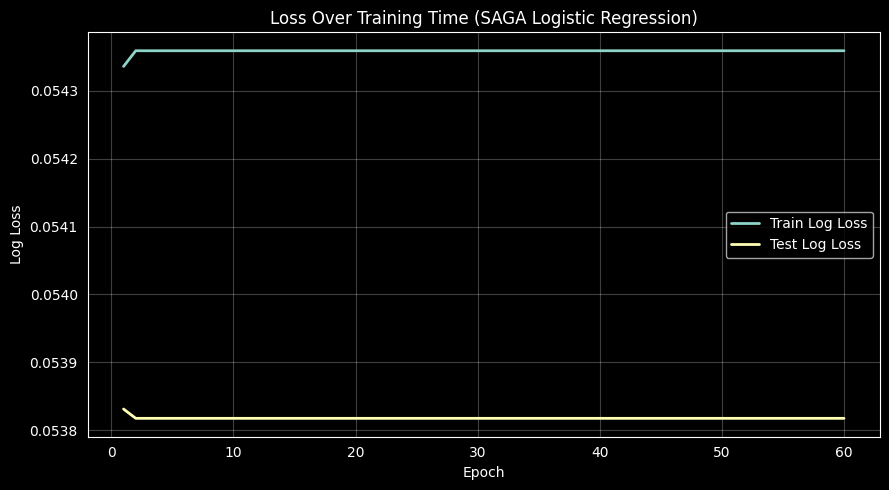

In [18]:
print("Max iterations allowed:", model.max_iter)
print("Iterations used (n_iter_):", model.n_iter_)
print("Approx epochs used:", int(model.n_iter_[0]))  # binary case

epochs = 60
train_loss = []
test_loss = []

loss_model = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=1,      # one solver pass each loop
    warm_start=True, # continue training from previous loop
    random_state=42,
    verbose=0
)

for epoch in range(epochs):
    loss_model.fit(X_train, y_train)

    train_probs = loss_model.predict_proba(X_train)
    test_probs = loss_model.predict_proba(X_test)

    train_loss.append(log_loss(y_train, train_probs, labels=loss_model.classes_))
    test_loss.append(log_loss(y_test, test_probs, labels=loss_model.classes_))

plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), train_loss, label='Train Log Loss', linewidth=2)
plt.plot(range(1, epochs + 1), test_loss, label='Test Log Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.title('Loss Over Training Time (SAGA Logistic Regression)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Exporting

Let's export our model and prepare it for testing. 

In [19]:
sp.save_npz('csv/X_test.npz', X_test)
y_test.to_csv('csv/y_test.csv', index=False)

joblib.dump(model, "csv/sentiment_model.pkl")


['csv/sentiment_model.pkl']